In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.lines import Line2D
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

# import thetaflow as thf
import modelnn2 as thf

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1781089141.158076    9484 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781089141.199437    9484 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781089142.683783    9484 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781089143.998212    9484 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../Cross Validation Data/train_data_small.parquet')
metadata_test = pq.read_metadata('../Cross Validation Data/test_data_small.parquet')
# metadata_train = pq.read_metadata('../../train_data.parquet')
# metadata_test = pq.read_metadata('../../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

96 features
225000 colunas - Treino
75000 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../Cross Validation Data/train_data_small.parquet"
parquet_file_path_test = "../Cross Validation Data/test_data_small.parquet"
# parquet_file_path_train = "../../train_data.parquet"
# parquet_file_path_test = "../../test_data.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

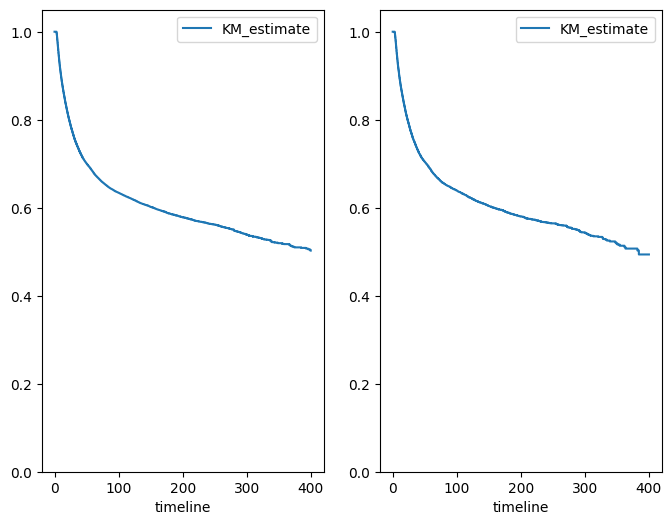

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

### Splitting data into linear components and neural network inputs

In [5]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

In [6]:
linear_columns = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11]
neuralnet_columns = [i for i in np.arange(X_train.shape[1]) if i not in linear_columns]

z_train = X_train.iloc[:, linear_columns]
# z_train.insert(0, "intercept", 1.0)
X_train_nn = X_train.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
# W_train_nn = np.linalg.inv( z_train.T @ z_train ) @ z_train.T @ X_train_nn

# By using @, the pandas environment breaks, since z_train and W_train_nn do not share colum names
# z_proj_X_train = np.dot(z_train, W_train_nn)

# Remove the projection of z_train from the matrix to be fed to the neural network
# X_train_nn = X_train_nn - z_proj_X_train

z_test = X_test.iloc[:, linear_columns]
# z_test.insert(0, "intercept", 1.0)
X_test_nn = X_test.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
# W_test_nn = np.linalg.inv( z_test.T @ z_test ) @ z_test.T @ X_test_nn
# z_proj_X_test = np.dot(z_test, W_test_nn)
# X_test_nn = X_test_nn - z_proj_X_test

data_train = [z_train, y_train, delta_train]
data_test = [z_test, y_test, delta_test]

display( z_train.head(3) )
display( X_train_nn.head(3) )

,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
0,-1.283593,0,0,0,1,0,0,0,0,0
1,-0.582427,0,0,0,0,0,0,0,0,0
2,-0.757718,0,0,0,0,0,1,0,0,0


,horas_semanais,qtd_dias_afastamento,escolaridade_5 ano completo,escolaridade_6 a 9 ano incompleto,escolaridade_analfabeto,escolaridade_ate 5 ano incompleto,escolaridade_doutorado,escolaridade_fundamental completo,escolaridade_medio incompleto,escolaridade_mestrado,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.39963,-0.15985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## Defining Accelerated Failure Time model structures

In [7]:
import utils_aft as aft

I0000 00:00:1781089144.937770    9484 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17768 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:01:00.0, compute capability: 8.6


### Exponential model

In [8]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]
seed = 10
exp_parameters, exp_loss = aft.get_simple_model( dist  = "exponential", theta_init = None )
simple_exp_model = thf.ModelNN(exp_parameters, exp_loss, None, None, None, input_dim = (1,), seed = seed)
simple_exp_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                             shuffle = True,
                             get_covariances = True,
                             validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                             force_training_validation = False,
                             optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                             optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                             early_stopping = True, early_stopping_patience = 10, 
                             early_stopping_warmup = 10,
                             reduce_lr = True, reduce_lr_warmup = 0,
                             reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                             reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                             deterministic = True,
                             verbose = True, print_freq = 1,
                             train_batch_size = None, val_batch_size = None,
                             buffer_size = None, gradient_accumulation_steps = None)

init_scale = simple_exp_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 89 / 5000 ]  | Loss:  0.877103806 | Best Loss:  0.877097845 | Speed:  50  epoch/s    | Elapsed Time:  1.74825525  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 5.298 seconds.

-------------------- Optimal parameters ----------
scale: [15.479222]


I0000 00:00:1781089151.370281    9484 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x634bf1b8d0d0


In [9]:
# Exponential
exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast = \
aft.build_AFT_model( z_train, dist = "exponential", theta_init = {"scale": init_scale}, beta_init = None )

In [10]:
with tf.device("/GPU:0"):
    seed = 10
    exp_model = thf.ModelNN(exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast,
                            input_dim = (X_train_nn.shape[1],), seed = seed)
    exp_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    exp_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                          shuffle = True,
                          get_covariances = True,
                          validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                          force_training_validation = False,
                          optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                          optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                          fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                          early_stopping = True, early_stopping_patience = 10, 
                          early_stopping_warmup = 50,
                          reduce_lr = True, reduce_lr_warmup = 0,
                          reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                          # reduce_lr_factor = 0.5, reduce_lr_min_delta = 2.0, reduce_lr_patience = 5,
                          reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                          fine_tune = True,
                          finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                          finetune_early_stopping_warmup = 50,
                          finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                          finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                          # finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0, finetune_reduce_lr_patience = 5,
                          finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                          deterministic = True,
                          verbose = True, print_freq = 1,
                          train_batch_size = None, val_batch_size = None,
                          buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 192 / 5000 ]  | Loss:  0.786127806 | Best Loss:  0.787114918 | Speed:  33  epoch/s    | Elapsed Time:  5.70473  s      
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 149 / 5000 ]  | Loss:  0.750705183 | Best Loss:  0.750783324 | Speed:  44  epoch/s    | Elapsed Time:  3.35970688  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 13.749 seconds.


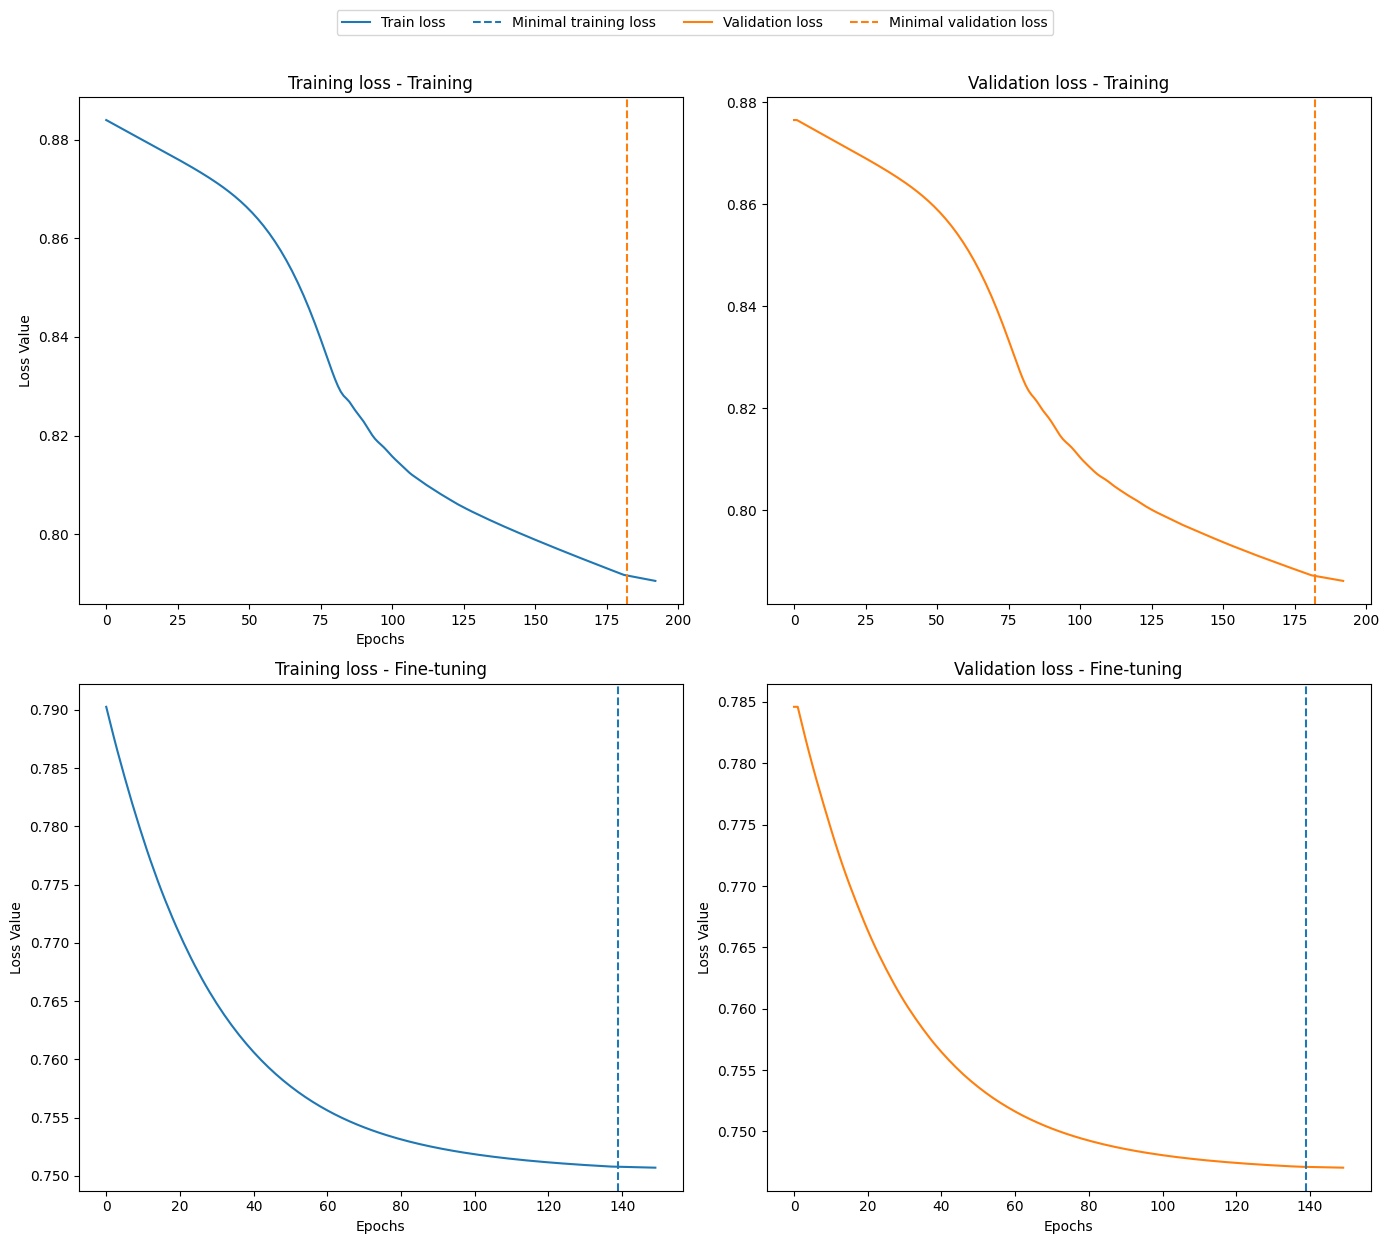

In [11]:
utils.plot_model_convergence( exp_model )

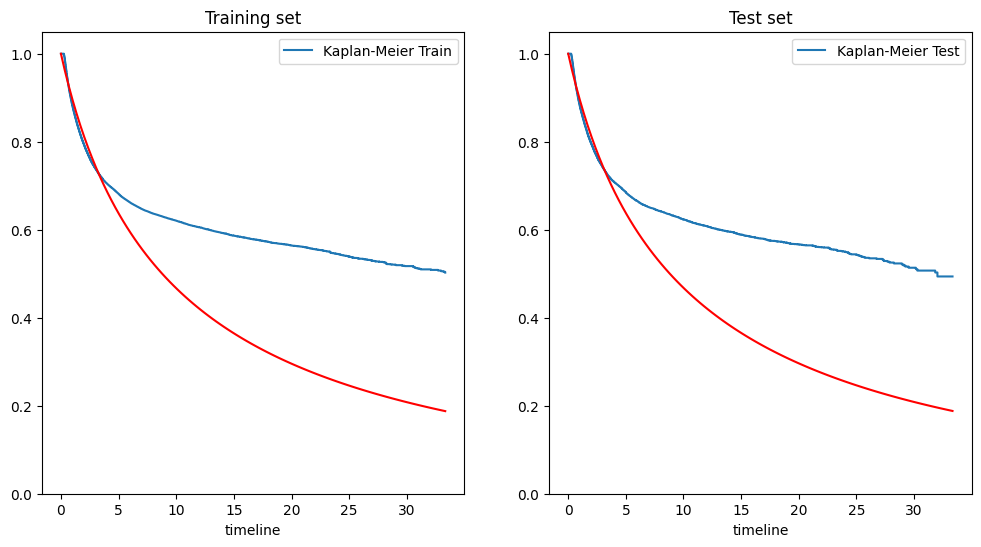

In [12]:
results_exp = aft.get_survival_exp(exp_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_exp["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_exp["S_ts_train"].shape[1]), size = np.min([n_max, results_exp["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_exp["S_ts_test"].shape[1]), size = np.min([n_max, results_exp["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_exp["ts_grid"].flatten(),
                           results_exp["S_ts_train"][:, train_idx], results_exp["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [13]:
aft.summary_betas( exp_model, z_train.columns )

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2716: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.555532,0.005412,102.638650,0.000000,(0.5449 ; 0.5661)
sexo_feminino,-0.005336,0.010044,-0.531307,0.595206,(-0.025 ; 0.0143)
raca_amarela,-0.108296,0.045496,-2.380323,0.017297,(-0.1975 ; -0.0191)
raca_indigena,-0.075438,0.091158,-0.827552,0.407924,(-0.2541 ; 0.1032)
raca_parda,-0.014067,0.010733,-1.310621,0.189986,(-0.0351 ; 0.007)
raca_preta,-0.075779,0.018310,-4.138595,0.000035,(-0.1117 ; -0.0399)
faixa_remuneracao_media_2 a 4 SM,0.523252,0.015502,33.754061,0.000000,(0.4929 ; 0.5536)
faixa_remuneracao_media_4 a 7 SM,0.611446,0.026393,23.166667,0.000000,(0.5597 ; 0.6632)
faixa_remuneracao_media_até 1 SM,-0.781389,0.011395,-68.574908,0.000000,(-0.8037 ; -0.7591)
faixa_remuneracao_media_mais de 7 SM,0.661665,0.030588,21.631642,0.000000,(0.6017 ; 0.7216)


### Weibull model

In [14]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    weibull_parameters, weibull_loss = aft.get_simple_model( dist  = "weibull", theta_init = None )
    simple_weibull_model = thf.ModelNN(weibull_parameters, weibull_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_weibull_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                     shuffle = True,
                                     get_covariances = True,
                                     validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                     force_training_validation = False,
                                     optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                     optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                     early_stopping = True, early_stopping_patience = 10,
                                     early_stopping_warmup = 10,
                                     reduce_lr = True, reduce_lr_warmup = 0,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                                     reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                     deterministic = True,
                                     verbose = True, print_freq = 1,
                                     train_batch_size = None, val_batch_size = None,
                                     buffer_size = None, gradient_accumulation_steps = None)

init_shape = simple_weibull_model.predict("shape")
init_scale = simple_weibull_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("shape: {}".format(init_shape))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 441 / 5000 ]  | Loss:  0.859828115 | Best Loss:  0.859828055 | Speed:  82  epoch/s    | Elapsed Time:  5.3402133  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 6.944 seconds.

-------------------- Optimal parameters ----------
shape: [0.7307338]
scale: [22.284575]


In [15]:
# Weibull
weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast = \
aft.build_AFT_model( z_train, dist  = "weibull", theta_init = {"shape": init_shape, "scale": init_scale}, beta_init = None )

In [16]:
with tf.device("/GPU:0"):
    seed = 10
    weibull_model = thf.ModelNN(weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast,
                                input_dim = (X_train_nn.shape[1],), seed = seed)
    weibull_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    weibull_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                              force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 10, 
                              early_stopping_warmup = 50,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                              finetune_early_stopping_warmup = 50,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                              # finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0, finetune_reduce_lr_patience = 5,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1,
                              train_batch_size = None, val_batch_size = None,
                              buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 206 / 5000 ]  | Loss:  0.777086377 | Best Loss:  0.777981877 | Speed:  27  epoch/s    | Elapsed Time:  7.48453093  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 122 / 5000 ]  | Loss:  0.746311128 | Best Loss:  0.746395469 | Speed:  85  epoch/s    | Elapsed Time:  1.42681646  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 13.451 seconds.


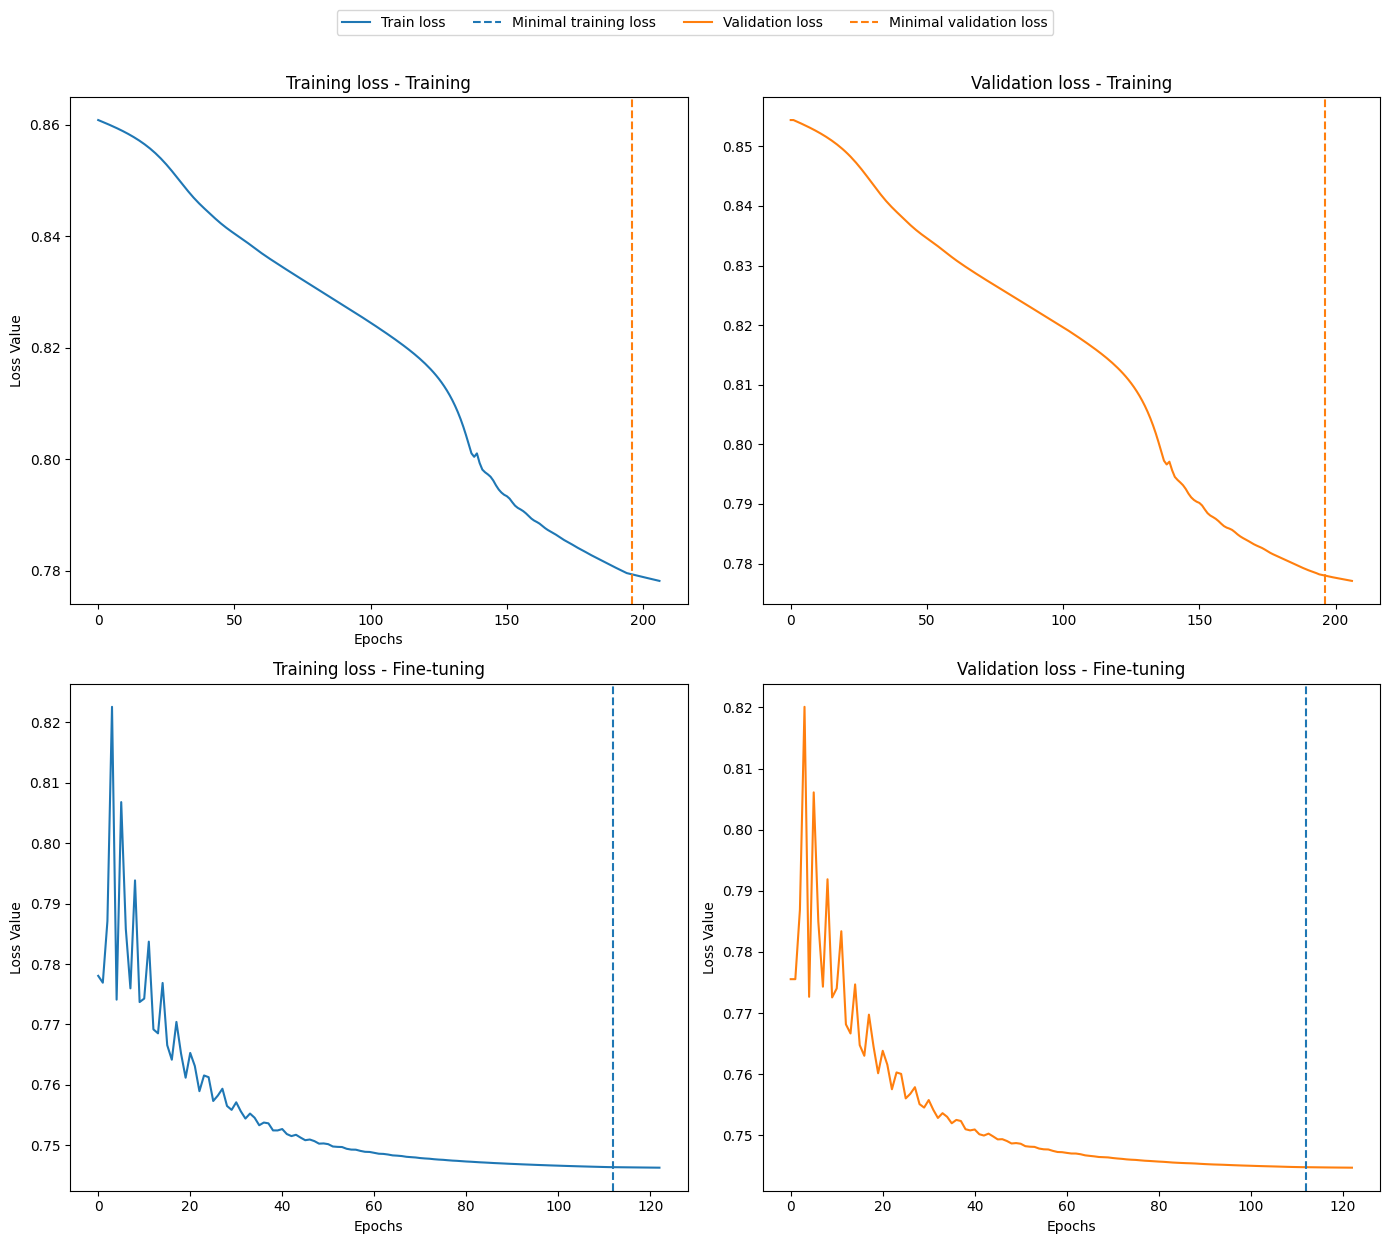

In [17]:
utils.plot_model_convergence( weibull_model )

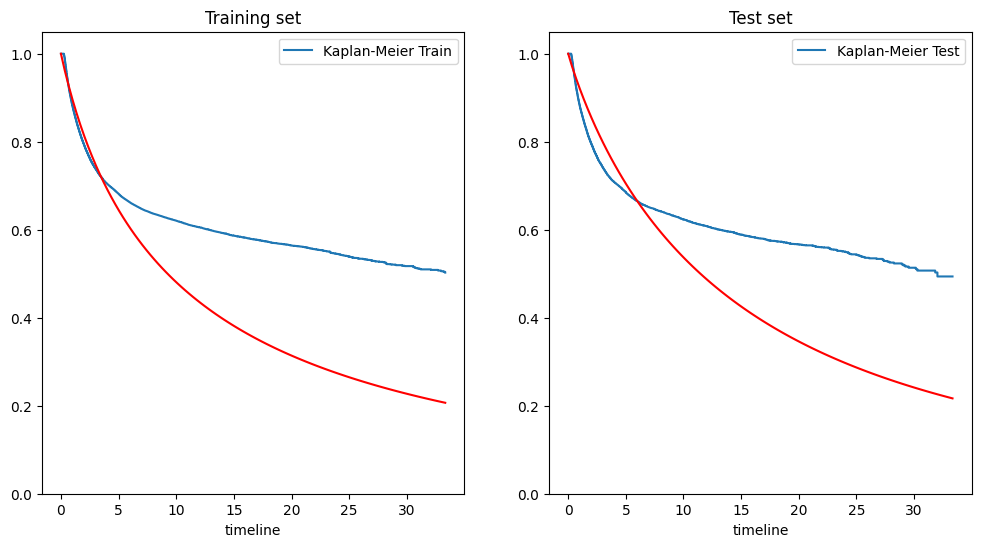

In [18]:
results_weibull = aft.get_survival_weibull(weibull_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_weibull["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_weibull["S_ts_train"].shape[1]), size = np.min([n_max, results_weibull["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_weibull["S_ts_test"].shape[1]), size = np.min([n_max, results_weibull["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_weibull["ts_grid"].flatten(),
                           results_weibull["S_ts_train"][:, train_idx], results_weibull["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [19]:
aft.summary_betas( weibull_model, z_train.columns )

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2716: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.551616,0.005643,97.749220,0.000000e+00,(0.5406 ; 0.5627)
sexo_feminino,-0.053427,0.010611,-5.035306,4.770862e-07,(-0.0742 ; -0.0326)
raca_amarela,-0.190687,0.045917,-4.152819,3.284042e-05,(-0.2807 ; -0.1007)
raca_indigena,-0.196282,0.091273,-2.150492,3.151629e-02,(-0.3752 ; -0.0174)
raca_parda,-0.111423,0.011562,-9.636801,0.000000e+00,(-0.1341 ; -0.0888)
raca_preta,-0.156795,0.018806,-8.337481,0.000000e+00,(-0.1937 ; -0.1199)
faixa_remuneracao_media_2 a 4 SM,0.490299,0.016247,30.178506,0.000000e+00,(0.4585 ; 0.5221)
faixa_remuneracao_media_4 a 7 SM,0.574454,0.027941,20.559882,0.000000e+00,(0.5197 ; 0.6292)
faixa_remuneracao_media_até 1 SM,-0.789597,0.011664,-67.694954,0.000000e+00,(-0.8125 ; -0.7667)
faixa_remuneracao_media_mais de 7 SM,0.608374,0.032728,18.588667,0.000000e+00,(0.5442 ; 0.6725)


### Log-normal model

In [20]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    lognormal_parameters, lognormal_loss = aft.get_simple_model( dist  = "lognormal", theta_init = None )
    simple_lognormal_model = thf.ModelNN(lognormal_parameters, lognormal_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_lognormal_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                       shuffle = True,
                                       get_covariances = True,
                                       validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                       force_training_validation = False,
                                       optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                       optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                       early_stopping = True, early_stopping_patience = 10,
                                       early_stopping_warmup = 10,
                                       reduce_lr = True, reduce_lr_warmup = 0,
                                       reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                                       reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                       deterministic = True,
                                       verbose = True, print_freq = 1,
                                       train_batch_size = None, val_batch_size = None,
                                       buffer_size = None, gradient_accumulation_steps = None)

init_mu = simple_lognormal_model.predict("mu")
init_scale = simple_lognormal_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("mu: {}".format(init_mu))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 45 / 5000 ]  | Loss:  0.839108884 | Best Loss:  0.834803402 | Speed:  36  epoch/s    | Elapsed Time:  1.24909759  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 3.397 seconds.

-------------------- Optimal parameters ----------
mu: [2.2411416]
scale: [1.7432594]


In [21]:
# Log-normal
lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast = \
aft.build_AFT_model( z_train, dist  = "lognormal", theta_init = {"mu": init_mu, "scale": init_scale}, beta_init = None )

In [22]:
with tf.device("/GPU:0"):
    seed = 10
    lognormal_model = thf.ModelNN(lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast,
                                  input_dim = (X_train_nn.shape[1],), seed = seed)
    lognormal_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    lognormal_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                early_stopping = True, early_stopping_patience = 10, 
                                early_stopping_warmup = 50,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                fine_tune = True,
                                finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                finetune_early_stopping_warmup = 50,
                                finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                                finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 154 / 5000 ]  | Loss:  0.755970478 | Best Loss:  0.756885409 | Speed:  25  epoch/s    | Elapsed Time:  6.03179264  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 122 / 5000 ]  | Loss:  0.729390264 | Best Loss:  0.729474247 | Speed:  40  epoch/s    | Elapsed Time:  3.0258739  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 14.138 seconds.


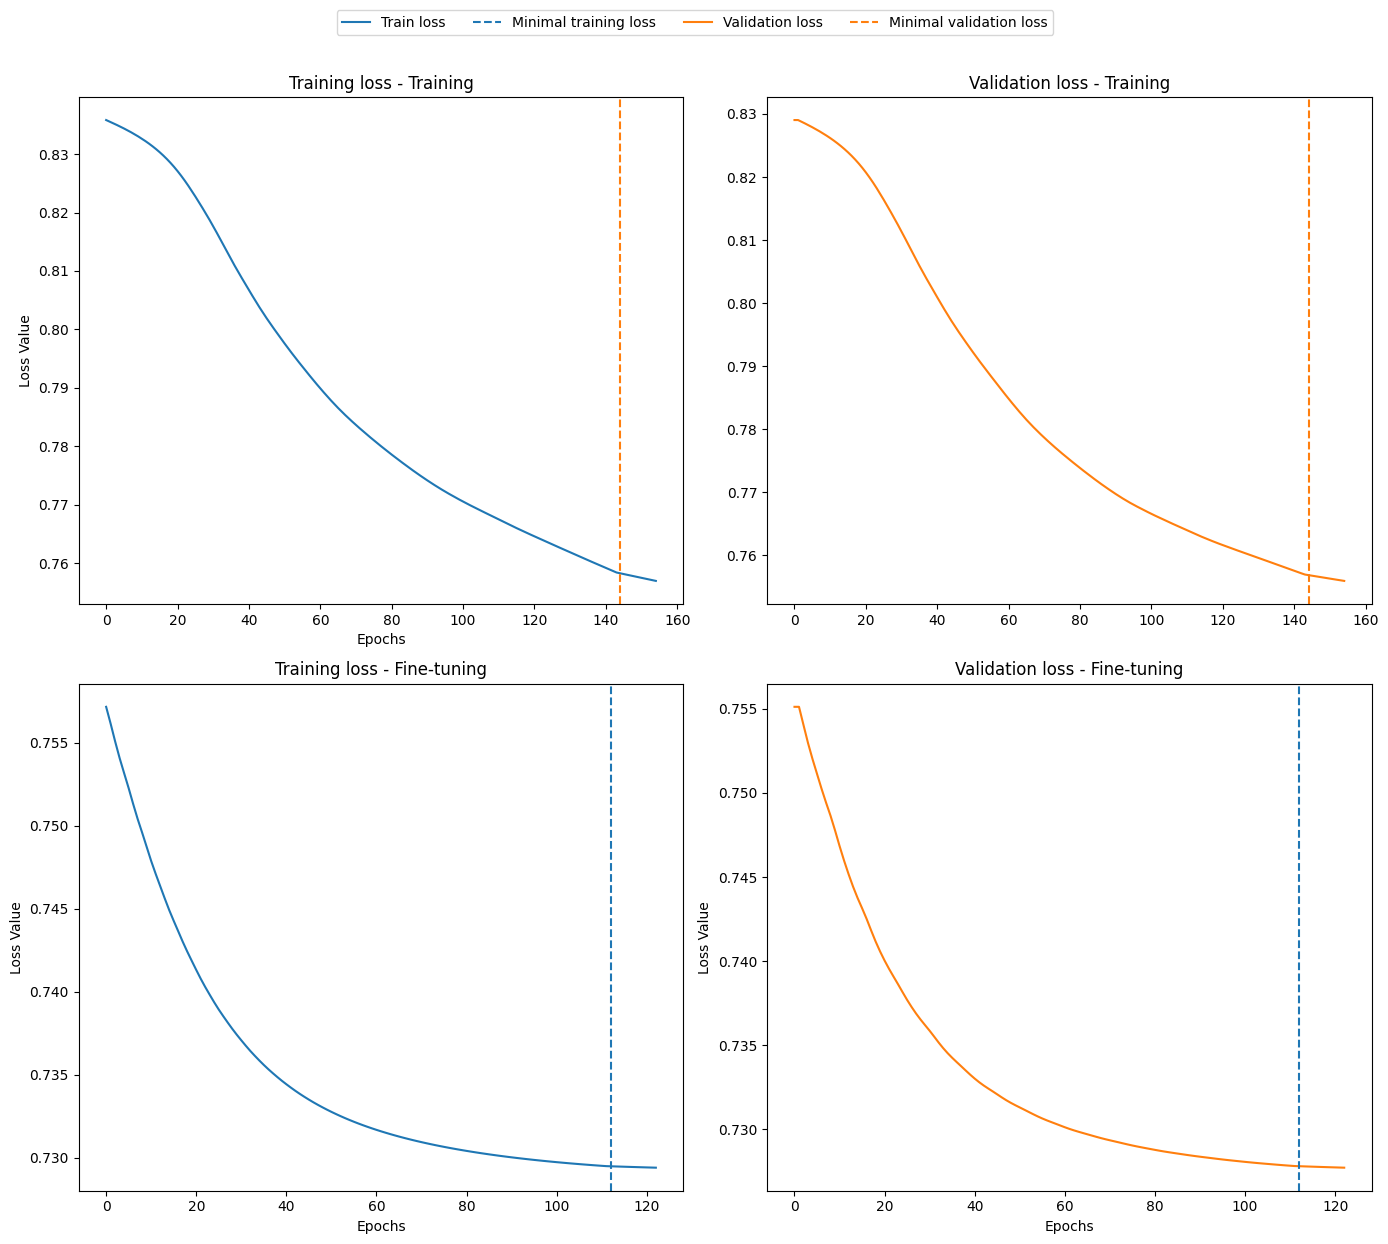

In [23]:
utils.plot_model_convergence( lognormal_model )

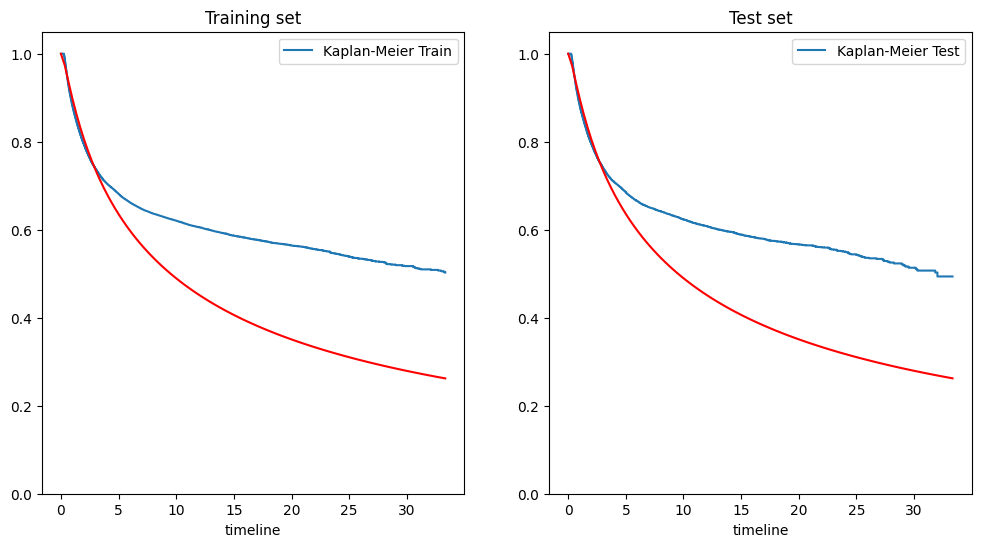

In [24]:
results_lognormal = aft.get_survival_lognormal(lognormal_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_lognormal["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_lognormal["S_ts_train"].shape[1]), size = np.min([n_max, results_lognormal["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_lognormal["S_ts_test"].shape[1]), size = np.min([n_max, results_lognormal["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_lognormal["ts_grid"].flatten(),
                           results_lognormal["S_ts_train"][:, train_idx], results_lognormal["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [25]:
aft.summary_betas( lognormal_model, z_train.columns )

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2716: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.428609,0.005192,82.550418,0.000000,(0.4184 ; 0.4388)
sexo_feminino,0.030569,0.010279,2.973975,0.002940,(0.0104 ; 0.0507)
raca_amarela,-0.124859,0.045322,-2.754938,0.005870,(-0.2137 ; -0.036)
raca_indigena,-0.178302,0.093138,-1.914383,0.055571,(-0.3609 ; 0.0042)
raca_parda,-0.033906,0.010748,-3.154524,0.001608,(-0.055 ; -0.0128)
raca_preta,-0.087679,0.018464,-4.748563,0.000002,(-0.1239 ; -0.0515)
faixa_remuneracao_media_2 a 4 SM,0.479521,0.014943,32.089459,0.000000,(0.4502 ; 0.5088)
faixa_remuneracao_media_4 a 7 SM,0.577614,0.026194,22.051636,0.000000,(0.5263 ; 0.629)
faixa_remuneracao_media_até 1 SM,-0.723518,0.011955,-60.519566,0.000000,(-0.7469 ; -0.7001)
faixa_remuneracao_media_mais de 7 SM,0.648626,0.031434,20.634310,0.000000,(0.587 ; 0.7102)


### Log-logistic model

In [26]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    loglogistic_parameters, loglogistic_loss = aft.get_simple_model( dist  = "loglogistic", theta_init = None )
    simple_loglogistic_model = thf.ModelNN(loglogistic_parameters, loglogistic_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_loglogistic_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                         shuffle = True,
                                         get_covariances = True,
                                         validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                         force_training_validation = False,
                                         optimizer_independent = optimizers.Adam(learning_rate = 0.1),
                                         optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                         early_stopping = True, early_stopping_patience = 10,
                                         early_stopping_warmup = 10,
                                         reduce_lr = True, reduce_lr_warmup = 0,
                                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                         deterministic = True,
                                         verbose = True, print_freq = 1,
                                         train_batch_size = None, val_batch_size = None,
                                         buffer_size = None, gradient_accumulation_steps = None)

init_shape = simple_loglogistic_model.predict("shape")
init_scale = simple_loglogistic_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("shape: {}".format(init_shape))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 52 / 5000 ]  | Loss:  0.848789871 | Best Loss:  0.847458065 | Speed:  84  epoch/s    | Elapsed Time:  0.613343239  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 2.471 seconds.

-------------------- Optimal parameters ----------
shape: [0.8928011]
scale: [10.875302]


In [27]:
# Log-logistic
loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast = \
aft.build_AFT_model( z_train, dist  = "loglogistic", theta_init = {"shape": init_shape, "scale": init_scale}, beta_init = None )

In [28]:
with tf.device("/GPU:0"):
    seed = 10
    loglogistic_model = thf.ModelNN(loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast,
                                    input_dim = (X_train_nn.shape[1],), seed = seed)
    loglogistic_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    loglogistic_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                                  shuffle = True,
                                  get_covariances = True,
                                  validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                  force_training_validation = False,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                                  fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                  early_stopping = True, early_stopping_patience = 10, 
                                  early_stopping_warmup = 50,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                                  reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                  fine_tune = True,
                                  finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                                  finetune_early_stopping_warmup = 50,
                                  finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                  finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                                  finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                  deterministic = True,
                                  verbose = True, print_freq = 1,
                                  train_batch_size = None, val_batch_size = None,
                                  buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 422 / 5000 ]  | Loss:  0.747351587 | Best Loss:  0.747320473 | Speed:  31  epoch/s    | Elapsed Time:  13.6054649  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 85 / 5000 ]  | Loss:  0.718040109 | Best Loss:  0.718114197 | Speed:  44  epoch/s    | Elapsed Time:  1.90317035  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 19.462 seconds.


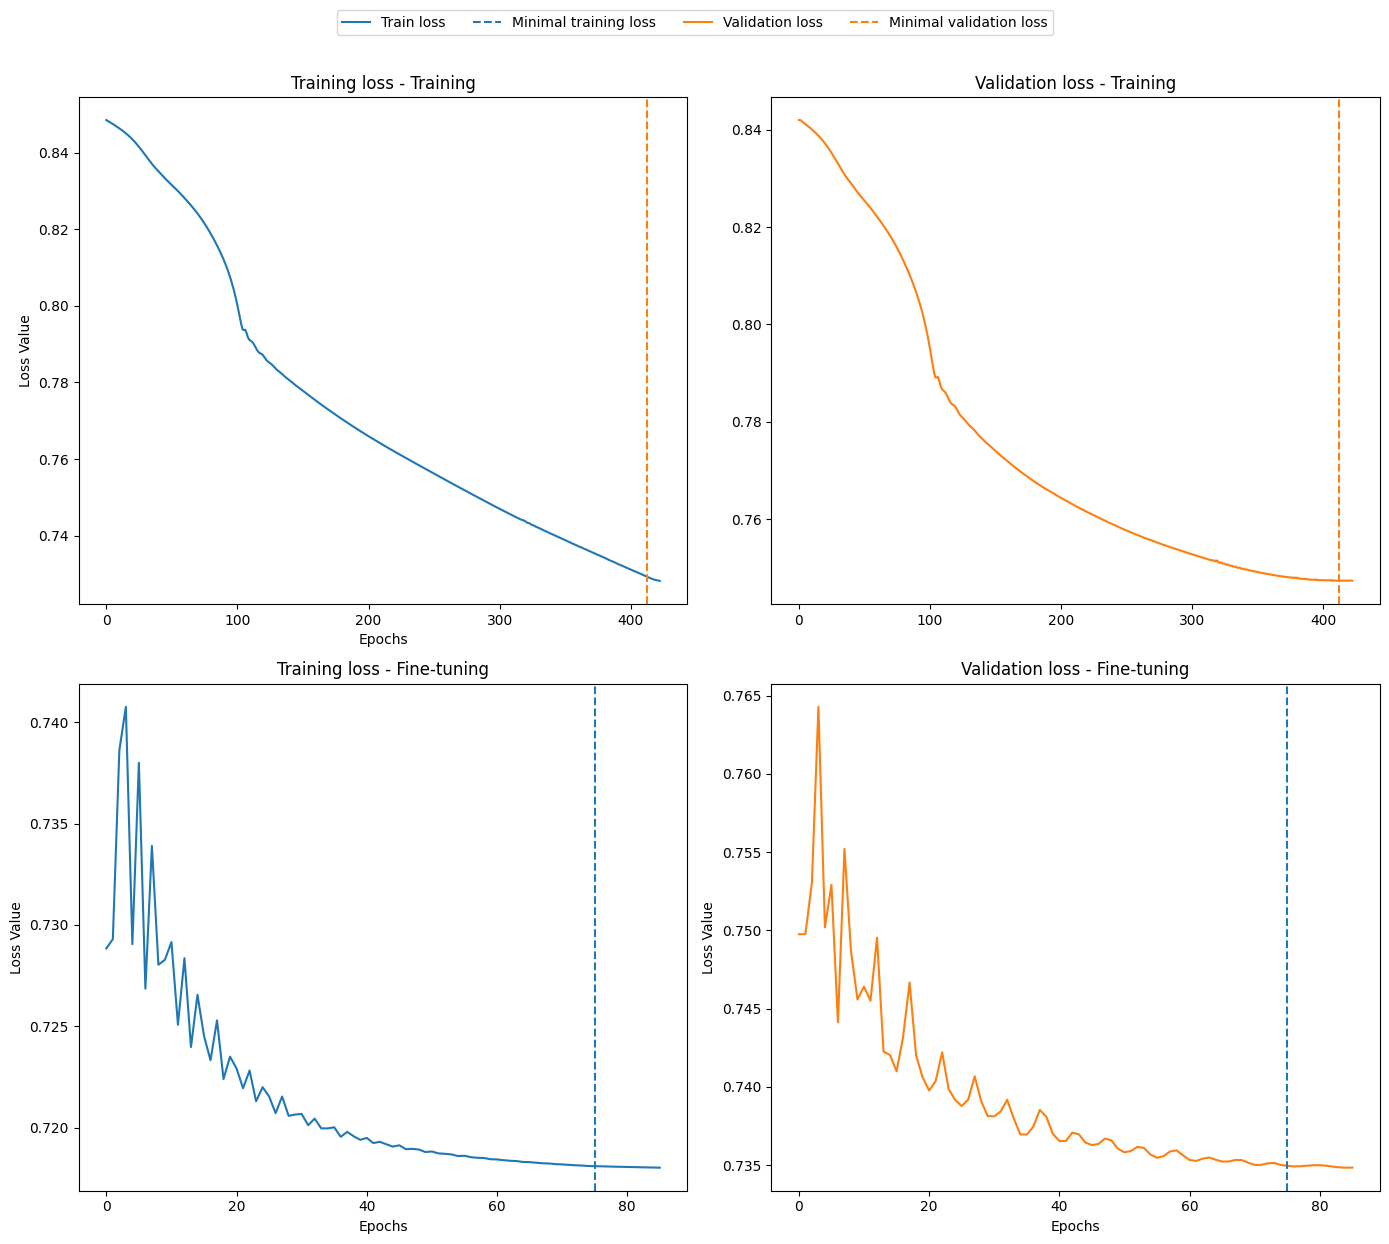

In [29]:
utils.plot_model_convergence( loglogistic_model )

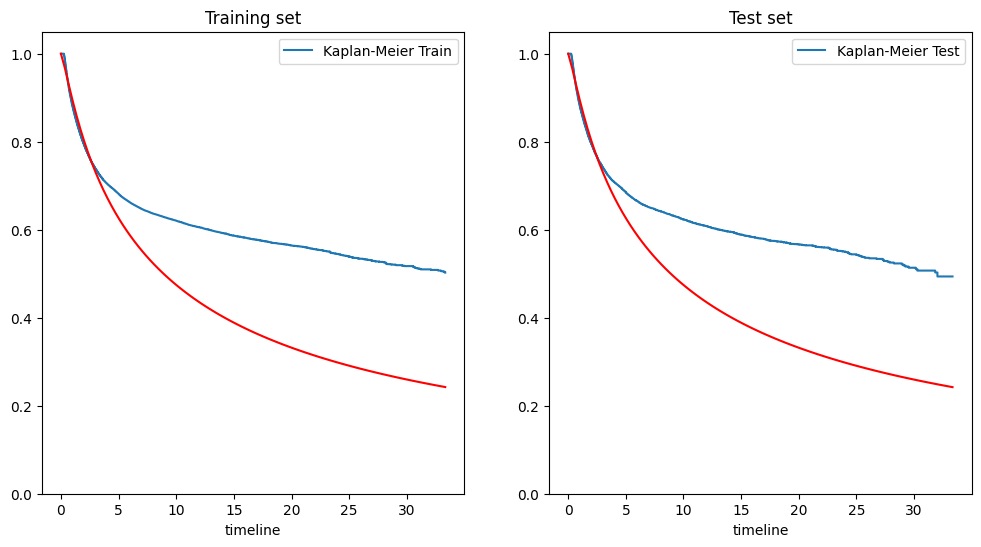

In [30]:
results_loglogistic = aft.get_survival_loglogistic(loglogistic_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 2000
n_max = results_loglogistic["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_loglogistic["S_ts_train"].shape[1]), size = np.min([n_max, results_loglogistic["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_loglogistic["S_ts_test"].shape[1]), size = np.min([n_max, results_loglogistic["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_loglogistic["ts_grid"].flatten(),
                           results_loglogistic["S_ts_train"][:, train_idx], results_loglogistic["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [31]:
aft.summary_betas( loglogistic_model, z_train.columns )

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2716: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.470625,0.005080,92.646844,0.000000e+00,(0.4607 ; 0.4806)
sexo_feminino,-0.000591,0.009652,-0.061211,9.511909e-01,(-0.0195 ; 0.0183)
raca_amarela,-0.111425,0.042941,-2.594859,9.462959e-03,(-0.1956 ; -0.0273)
raca_indigena,-0.187501,0.086925,-2.157049,3.100186e-02,(-0.3579 ; -0.0171)
raca_parda,-0.053505,0.010133,-5.280253,1.290059e-07,(-0.0734 ; -0.0336)
raca_preta,-0.081521,0.017346,-4.699789,2.604298e-06,(-0.1155 ; -0.0475)
faixa_remuneracao_media_2 a 4 SM,0.536164,0.014562,36.818237,0.000000e+00,(0.5076 ; 0.5647)
faixa_remuneracao_media_4 a 7 SM,0.625463,0.025738,24.301590,0.000000e+00,(0.575 ; 0.6759)
faixa_remuneracao_media_até 1 SM,-0.737004,0.010853,-67.906982,0.000000e+00,(-0.7583 ; -0.7157)
faixa_remuneracao_media_mais de 7 SM,0.679485,0.030266,22.450159,0.000000e+00,(0.6202 ; 0.7388)


### Birnbaun-Saunders model

In [32]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    bs_parameters, bs_loss = aft.get_simple_model( dist  = "bs", theta_init = None )
    simple_bs_model = thf.ModelNN(bs_parameters, bs_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_bs_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.05),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.05),
                                early_stopping = True, early_stopping_patience = 10,
                                early_stopping_warmup = 10,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

init_shape = simple_bs_model.predict("shape")
init_scale = simple_bs_model.predict("scale")

print("\n-------------------- Optimal parameters ----------")
print("shape: {}".format(init_shape))
print("scale: {}".format(init_scale))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 1780 / 5000 ]  | Loss:  0.790102422 | Best Loss:  0.790102422 | Speed:  75  epoch/s    | Elapsed Time:  23.4841595  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 25.694 seconds.

-------------------- Optimal parameters ----------
shape: [4.8789134]
scale: [37.68612]


In [33]:
# Birnbaun-Saunders (BS)
bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = \
aft.build_AFT_model( z_train, dist  = "bs", theta_init = {"shape": init_shape, "scale": init_scale}, beta_init = None )

In [34]:
with tf.device("/GPU:0"):
    seed = 10
    bs_model = thf.ModelNN(bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast,
                           input_dim = (X_train_nn.shape[1],), seed = seed)
    bs_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    bs_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                         shuffle = True,
                         get_covariances = True,
                         validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                         force_training_validation = False,
                         optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                         optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                         fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                         early_stopping = True, early_stopping_patience = 10, 
                         early_stopping_warmup = 50,
                         reduce_lr = True, reduce_lr_warmup = 0,
                         reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                         reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                         fine_tune = True,
                         finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                         finetune_early_stopping_warmup = 50,
                         finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                         finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                         finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                         deterministic = True,
                         verbose = True, print_freq = 1,
                         train_batch_size = None, val_batch_size = None,
                         buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 93 / 5000 ]  | Loss:  0.762990475 | Best Loss:  0.763853908 | Speed:  24  epoch/s    | Elapsed Time:  3.72352719  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 142 / 5000 ]  | Loss:  0.750804543 | Best Loss:  0.750873089 | Speed:  39  epoch/s    | Elapsed Time:  3.63012648  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 13.101 seconds.


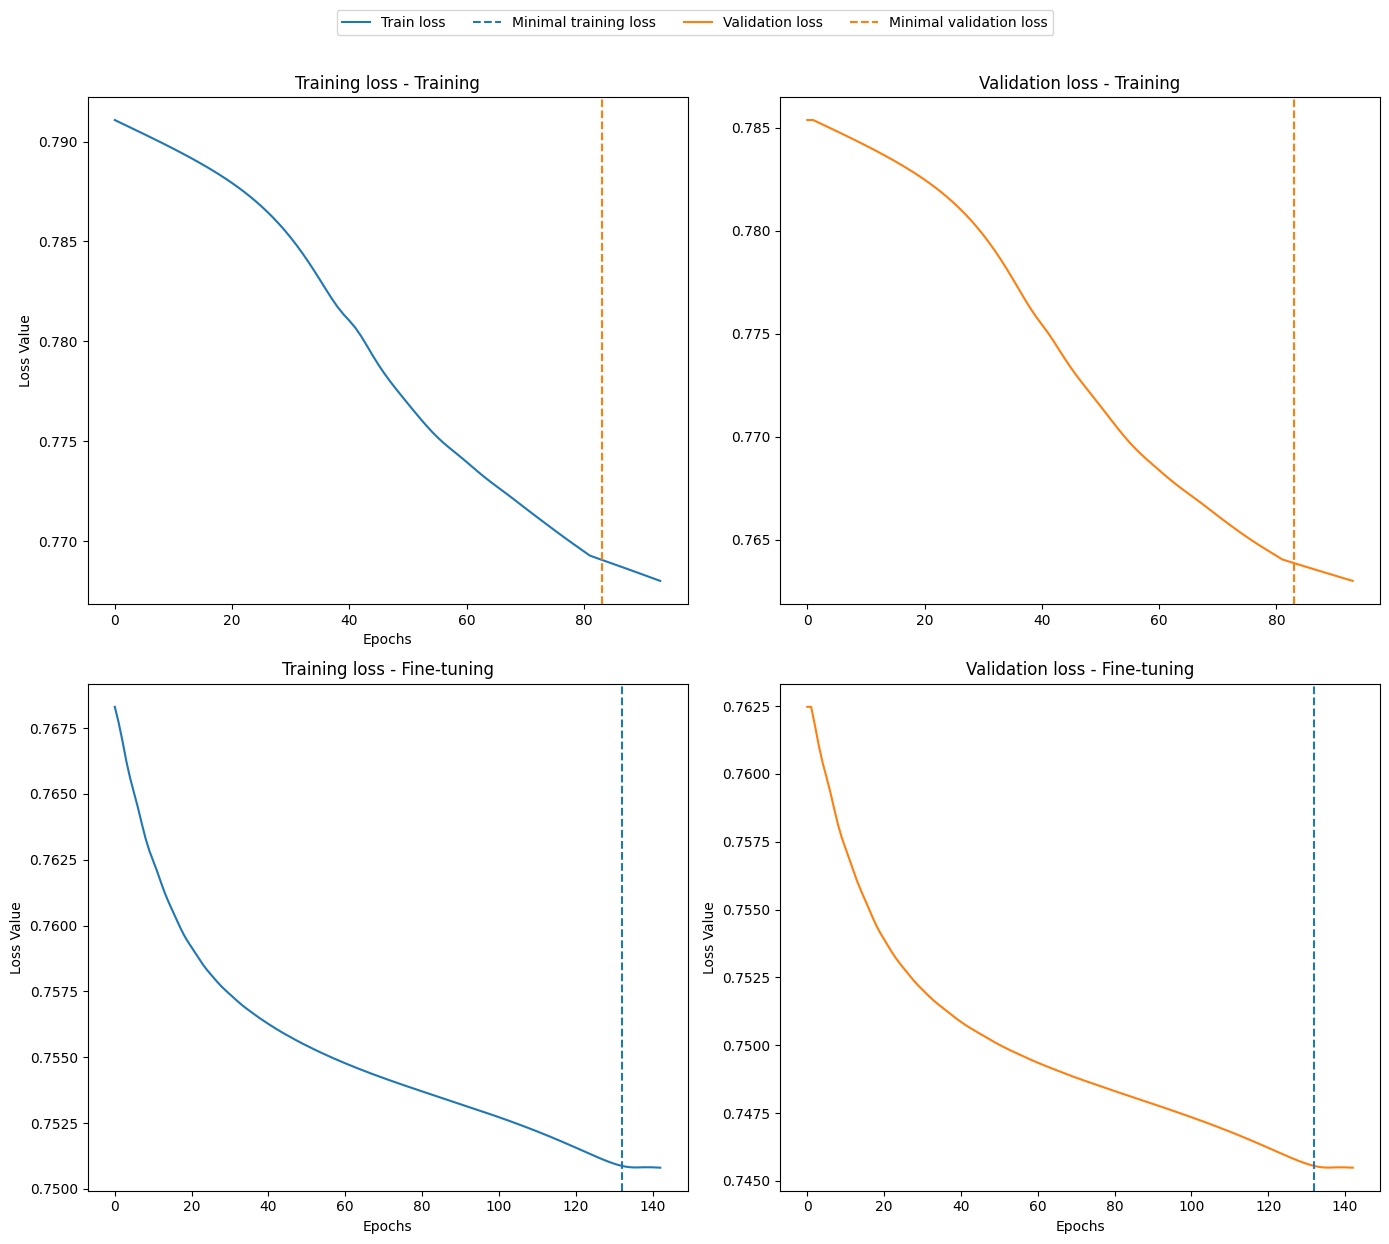

In [35]:
utils.plot_model_convergence( bs_model )

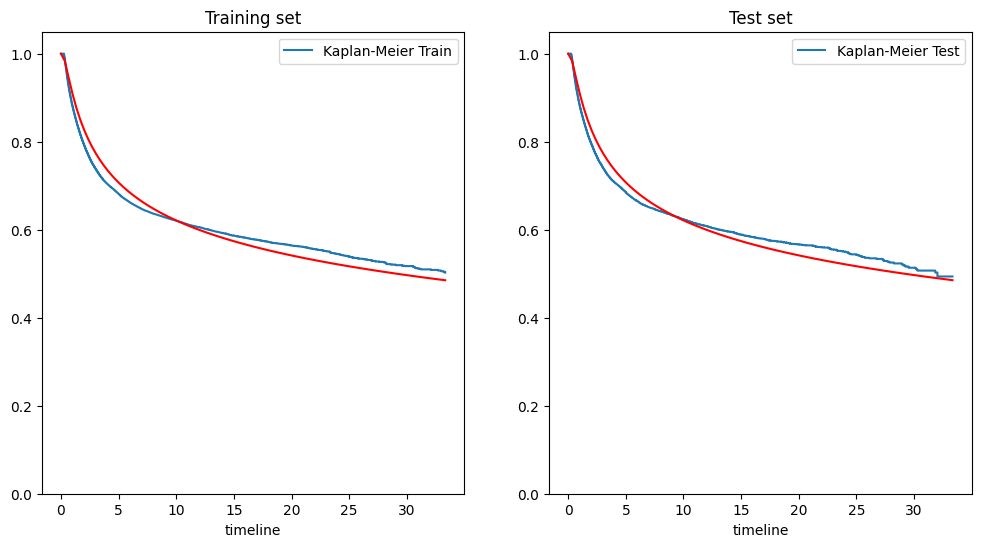

In [36]:
results_bs = aft.get_survival_bs(bs_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

# n_max = 10000
n_max = results_bs["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_bs["S_ts_train"].shape[1]), size = np.min([n_max, results_bs["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_bs["S_ts_test"].shape[1]), size = np.min([n_max, results_bs["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_bs["ts_grid"].flatten(),
                           results_bs["S_ts_train"][:, train_idx], results_bs["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = False, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [37]:
aft.summary_betas( bs_model, z_train.columns )

/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2716: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,0.242506,0.004978,48.714841,0.000000e+00,(0.2327 ; 0.2523)
sexo_feminino,-0.044499,0.010112,-4.400594,1.079551e-05,(-0.0643 ; -0.0247)
raca_amarela,-0.135049,0.045402,-2.974488,2.934776e-03,(-0.224 ; -0.0461)
raca_indigena,-0.246457,0.096394,-2.556767,1.056499e-02,(-0.4354 ; -0.0575)
raca_parda,-0.089699,0.010513,-8.532528,0.000000e+00,(-0.1103 ; -0.0691)
raca_preta,-0.130004,0.018379,-7.073431,1.511458e-12,(-0.166 ; -0.094)
faixa_remuneracao_media_2 a 4 SM,0.330877,0.013878,23.842074,0.000000e+00,(0.3037 ; 0.3581)
faixa_remuneracao_media_4 a 7 SM,0.464131,0.022513,20.616585,0.000000e+00,(0.42 ; 0.5083)
faixa_remuneracao_media_até 1 SM,-0.573385,0.012684,-45.206584,0.000000e+00,(-0.5982 ; -0.5485)
faixa_remuneracao_media_mais de 7 SM,0.688032,0.025848,26.618010,0.000000e+00,(0.6374 ; 0.7387)


## Comparing all models

In [38]:
# Takes only employees whose sallary is the standard (between 1 and 2 minimal salaries)
baseline_idx = (X_train.iloc[:, [8,9,10,11]] == 0).all(axis = 1)
X_baseline = X_train.loc[ baseline_idx , : ]
y_baseline = y_train[ baseline_idx ]
delta_baseline = delta_train[ baseline_idx ]

z_baseline = X_baseline.iloc[:, linear_columns]
z_baseline_tf = tf.cast(z_baseline, tf.float32)
X_baseline_nn = X_baseline.iloc[:, neuralnet_columns]
# y_baseline = 

ate1sm_idx = X_train["faixa_remuneracao_media_até 1 SM"] == 1
X_ate1sm = X_train.loc[ ate1sm_idx , : ]
y_ate1sm = y_train[ ate1sm_idx ]
delta_ate1sm = delta_train[ ate1sm_idx ]

z_ate1sm = X_ate1sm.iloc[:, linear_columns]
z_ate1sm_tf = tf.cast(z_ate1sm, tf.float32)
X_ate1sm_nn = X_ate1sm.iloc[:, neuralnet_columns]

In [40]:
results_exp_baseline = aft.get_survival_exp(exp_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_exp_ate1sm = aft.get_survival_exp(exp_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_weibull_baseline = aft.get_survival_weibull(weibull_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_weibull_ate1sm = aft.get_survival_weibull(weibull_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_lognormal_baseline = aft.get_survival_lognormal(lognormal_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_lognormal_ate1sm = aft.get_survival_lognormal(lognormal_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_loglogistic_baseline = aft.get_survival_loglogistic(loglogistic_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_loglogistic_ate1sm = aft.get_survival_loglogistic(loglogistic_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

results_bs_baseline = aft.get_survival_bs(bs_model, y_baseline, z_baseline_tf, X_baseline_nn, y_baseline, z_baseline_tf, X_baseline_nn, ngrid = 100)
results_bs_ate1sm = aft.get_survival_bs(bs_model, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, y_ate1sm, z_ate1sm_tf, X_ate1sm_nn, ngrid = 100)

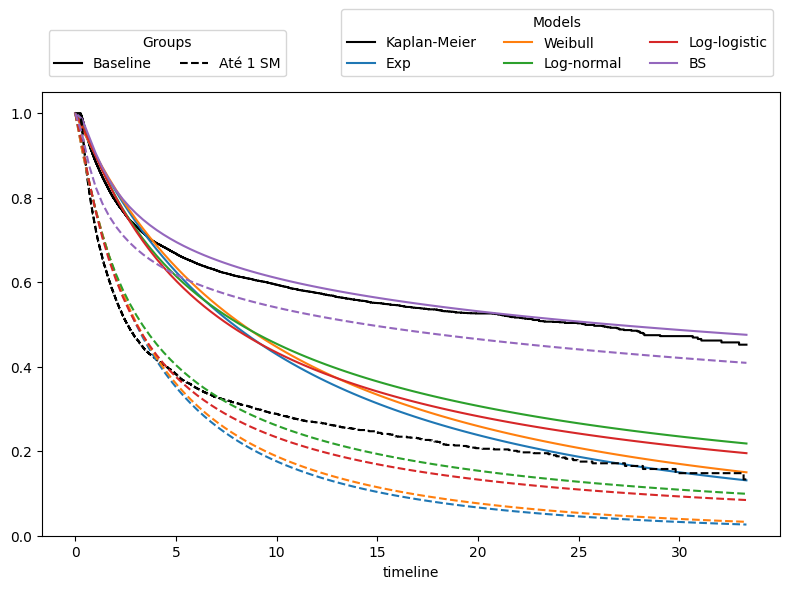

In [43]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# ax.plot(ts_grid.numpy().flatten(), np.mean( S_ts_baseline, axis = 1 ), color = colors[0])

km_baseline = lifelines.KaplanMeierFitter()
km_baseline.fit(y_baseline, delta_baseline)
km_baseline.plot(ax = ax, ci_show = False, show_censors = False, label = "Baseline", color = "black", linestyle = "-")
ax.set_ylim(0,1.05)

ax.plot(results_exp_baseline["ts_grid"].flatten(), np.mean( results_exp_baseline["S_ts_train"], axis = 1 ), color = colors[0], label = "Exp")
ax.plot(results_weibull_baseline["ts_grid"].flatten(), np.mean( results_weibull_baseline["S_ts_train"], axis = 1 ), color = colors[1], label = "Weibull")
ax.plot(results_lognormal_baseline["ts_grid"].flatten(), np.mean( results_lognormal_baseline["S_ts_train"], axis = 1 ), color = colors[2], label = "Weibull")
ax.plot(results_loglogistic_baseline["ts_grid"].flatten(), np.mean( results_loglogistic_baseline["S_ts_train"], axis = 1 ), color = colors[3], label = "Weibull")
ax.plot(results_bs_baseline["ts_grid"].flatten(), np.mean( results_bs_baseline["S_ts_train"], axis = 1 ), color = colors[4], label = "Weibull")

km_ate1sm = lifelines.KaplanMeierFitter()
km_ate1sm.fit(y_ate1sm, delta_ate1sm)
km_ate1sm.plot(ax = ax, ci_show = False, show_censors = False, label = "Até 1 SM", color = "black", linestyle = "--")
ax.set_ylim(0,1.05)

ax.plot(results_exp_ate1sm["ts_grid"].flatten(), np.mean( results_exp_ate1sm["S_ts_train"], axis = 1 ), color = colors[0], linestyle = "--")
ax.plot(results_weibull_ate1sm["ts_grid"].flatten(), np.mean( results_weibull_ate1sm["S_ts_train"], axis = 1 ), color = colors[1], linestyle = "--")
ax.plot(results_lognormal_ate1sm["ts_grid"].flatten(), np.mean( results_lognormal_ate1sm["S_ts_train"], axis = 1 ), color = colors[2], linestyle = "--")
ax.plot(results_loglogistic_ate1sm["ts_grid"].flatten(), np.mean( results_loglogistic_ate1sm["S_ts_train"], axis = 1 ), color = colors[3], linestyle = "--")
ax.plot(results_bs_ate1sm["ts_grid"].flatten(), np.mean( results_bs_ate1sm["S_ts_train"], axis = 1 ), color = colors[4], linestyle = "--")

# Custom handles for Line Styles (The Groups)
group_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Baseline'),
    Line2D([0], [0], color='black', linestyle='--', label='Até 1 SM')
]

# Custom handles for Colors (The Models)
model_handles = [
    Line2D([0], [0], color='black', linestyle='-', label='Kaplan-Meier'),
    Line2D([0], [0], color=colors[0], linestyle='-', label='Exp'),
    Line2D([0], [0], color=colors[1], linestyle='-', label='Weibull'),
    Line2D([0], [0], color=colors[2], linestyle='-', label='Log-normal'),
    Line2D([0], [0], color=colors[3], linestyle='-', label='Log-logistic'),
    Line2D([0], [0], color=colors[4], linestyle='-', label='BS')
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = ax.legend(
    handles = group_handles, 
    loc = 'lower left', 
    bbox_to_anchor = (0.0, 1.02), # Pushes it just above the top-left corner
    title = "Groups",
    ncol = 2                     # Lays items out horizontally
)

ax.add_artist(legend1) 

# Add the second legend (Models) - Anchored to the top right
ax.legend(
    handles = model_handles, 
    loc = 'lower right', 
    bbox_to_anchor = (1.0, 1.02), # Pushes it just above the top-right corner
    title = "Models",
    ncol = 3,                     # Lays items out horizontally
)

# Prevent the top legends from being clipped off the final image
plt.tight_layout() 
plt.show()

As it can be seen in the plot above, the Exponential, Weibull, Log-normal and Log-logistic models were not able to capture the tail behaviour of the times distributions, with quickly decaying survival functions. However, all these models were able to capture nicely the overall distance between the two groups under study (Baseline against "Até 1 SM"). The best averaged curve was given by the Birnbaun-Saunders model, which in the picture is indeed the model that best captures the survival in the baseline set. However, its predictions for the second group's survival function are highly overestimated, suggesting that even though the model was able to detect a statistically significant difference between the groups, all estimates are not reflecting reality.

Below, we quickly test, using the two groups, the assumption of proportional hazards. As it can be seen, we have evidence that the survival times can be viewed as a realization of a proportional hazards model.

<Axes: >

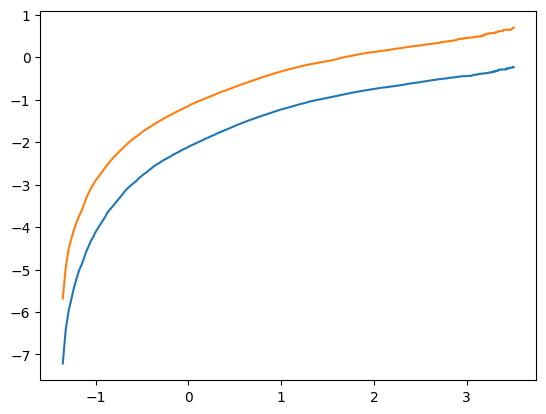

In [44]:
t_km_baseline = km_baseline.timeline
S_km_baseline = km_baseline.survival_function_.to_numpy().flatten()

t_km_ate1sm = km_ate1sm.timeline
S_km_ate1sm = km_ate1sm.survival_function_.to_numpy().flatten()

sns.lineplot(x = np.log(t_km_baseline), y = np.log(-np.log(S_km_baseline)))
sns.lineplot(x = np.log(t_km_ate1sm), y = np.log(-np.log(S_km_ate1sm)))

### Kw-CWG model

In [46]:
# Quickly fit a no-covariates model to obtain satisfactory initial points
no_covariates_data_train = [data_train[1], data_train[2]]

with tf.device("/GPU:0"):
    seed = 10
    kwcwg_parameters, kwcwg_loss = aft.get_simple_model( dist  = "kwcwg", theta_init = None )
    simple_kwcwg_model = thf.ModelNN(kwcwg_parameters, kwcwg_loss, None, None, None, input_dim = (1,), seed = seed)
    simple_kwcwg_model.train_model(epochs = 5000, x = None, data = no_covariates_data_train,
                                shuffle = True,
                                get_covariances = True,
                                validation = False, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                                force_training_validation = False,
                                optimizer_independent = optimizers.Adam(learning_rate = 0.0001),
                                optimizer_nn = optimizers.Adam(learning_rate = 0.0001),
                                early_stopping = True, early_stopping_patience = 10,
                                early_stopping_warmup = 10,
                                reduce_lr = True, reduce_lr_warmup = 0,
                                reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-8, reduce_lr_patience = 5,
                                reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                deterministic = True,
                                verbose = True, print_freq = 1,
                                train_batch_size = None, val_batch_size = None,
                                buffer_size = None, gradient_accumulation_steps = None)

init_a = simple_kwcwg_model.predict("a")
init_b = simple_kwcwg_model.predict("b")
init_alpha = simple_kwcwg_model.predict("alpha")
init_gamma = simple_kwcwg_model.predict("gamma")
init_lam = simple_kwcwg_model.predict("lam")

print("\n-------------------- Optimal parameters ----------")
print("a: {}".format(init_a))
print("b: {}".format(init_b))
print("alpha: {}".format(init_alpha))
print("gamma: {}".format(init_gamma))
print("lam: {}".format(init_lam))

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...

[!] FATAL: Gradients exploded to NaN/Inf at Epoch: 0

Done.
Extracting covariance structure.
Done.
Optimization finished in 2.101 seconds.

-------------------- Optimal parameters ----------
a: [1.]
b: [1.]
alpha: [0.5]
gamma: [1.]
lam: [1.]


/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2603: RuntimeWarning: Covariance matrix could not be computed because the log-likelihood Hessian is singular (or near singular).
The model may not be identified.

  warnings.warn(


In [ ]:
# Kumaraswamy complementary Weibull Geometric (Kw-CWG)
kwcwg_parameters, kwcwg_loss, kwcwg_neural_network, kwcwg_call, kwcwg_call_nolast = \
build_AFT_model( z_train, dist  = "kwcwg", theta_init = None, beta_init = None )

In [15]:
with tf.device("/GPU:0"):
    seed = 10
    kwcwg_model = thf.ModelNN(kwcwg_parameters, kwcwg_loss, kwcwg_neural_network, kwcwg_call, kwcwg_call_nolast,
                              input_dim = (X_train_nn.shape[1],), seed = seed)
    kwcwg_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    kwcwg_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                            shuffle = True,
                            get_covariances = True,
                            validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                            force_training_validation = False,
                            optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                            optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                            fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                            early_stopping = True, early_stopping_patience = 10, 
                            early_stopping_warmup = 50,
                            reduce_lr = True, reduce_lr_warmup = 0,
                            reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                            reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                            fine_tune = True,
                            finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                            finetune_early_stopping_warmup = 50,
                            finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                            finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-4, finetune_reduce_lr_patience = 5,
                            finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                            deterministic = True,
                            verbose = True, print_freq = 1,
                            train_batch_size = None, val_batch_size = None,
                            buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...

[!] FATAL: Gradients exploded to NaN/Inf at Epoch: 0

Done.
Initializing model fine tuning (only independent parameters and last-layer)

[!] FATAL: Gradients exploded to NaN/Inf at Epoch: 0

Done.
Extracting covariance structure.
Done.
Optimization finished in 5.391 seconds.


/home/garibay/codes/rais_analysis/Linear Final Models/modelnn2.py:2606: RuntimeWarning: Covariance matrix could not be computed because the log-likelihood Hessian is singular (or near singular).
The model may not be identified.

  warnings.warn(
W0000 00:00:1781069733.408317    4615 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: Input is not invertible.


In [ ]:
def loglikelihood_loss(model, nn_output, data):
            # Unpack your data tuple
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype = tf.float32)
            
            a = model.get_variable("a", nn_output)
            b = model.get_variable("b", nn_output)
            alpha = model.get_variable("alpha", nn_output)
            gamma = model.get_variable("gamma", nn_output)
            lam = model.get_variable("lam", nn_output)
            beta = model.get_variable("beta")[:,None]
            
            # Linear predictor and acceleration in time
            r_z = tf.matmul(z, beta)
            t0 = y * tf.math.exp(-r_z)
            log_t0 = tf.math.log(t0 + eps)

            alpha = tf.clip_by_value(alpha, 1e-5, 1-1e-5)
            log_a = tf.math.log(a)
            log_b = tf.math.log(b)
            log_alpha = tf.math.log(alpha)
            log_gamma = tf.math.log(gamma)
            log_lam = tf.math.log(lam)

            lambdat_gamma = (lam * t0)**gamma
            exp_lambdat_gamma = tf.math.exp( -lambdat_gamma )
            log_S_term = tf.math.log( 1 - ( alpha*(1-exp_lambdat_gamma) / (alpha + (1-alpha)*exp_lambdat_gamma) )**a )
            
            log_f_base = a*log_alpha + log_gamma + log_a + log_b + gamma*log_lam + (gamma-1)*log_t0 \
                         - lambdat_gamma + (a-1) * tf.math.log( 1 - exp_lambdat_gamma ) \
                         - (a+1) * tf.math.log( alpha + (1-alpha)*exp_lambdat_gamma ) \
                         + (b-1) * log_S_term
            log_S_base = b * log_S_term
            log_h_base = log_f_base - log_S_base
            
            # Evaluation of h_AFT
            log_h_AFT = log_h_base - r_z
            
            loglik_terms = delta * log_h_AFT + log_S_base
            return -tf.reduce_mean(loglik_terms)
            

In [ ]:
    def get_survival_kwcwg(model, y_train, z_train, X_train, y_test, z_test, X_test, ngrid = 100):
    eps = tf.constant(1.0e-7, dtype = tf.float32)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    beta = model.predict("beta")[:,None]


    # ------------------------------- Train -------------------------------
    a_train = pred_train["a"].numpy().flatten()
    b_train = pred_train["b"].numpy().flatten()
    alpha_train = pred_train["alpha"].numpy().flatten()
    gamma_train = pred_train["gamma"].numpy().flatten()
    lam_train = pred_train["lam"].numpy().flatten()
    
    alpha_train = tf.clip_by_value(alpha_train, 1e-5, 1-1e-5)
    log_a_train = tf.math.log(a_train)
    log_b_train = tf.math.log(b_train)
    log_alpha_train = tf.math.log(alpha_train)
    log_gamma_train = tf.math.log(gamma_train)
    log_lam_train = tf.math.log(lam_train)

    ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), ngrid)[:,None]
    
    # Linear predictor and acceleration in time
    r_z_train = np.dot(z_train, beta).flatten()
    t0_grid_train = ts_grid * np.exp( -r_z_train )

    lambdat_gamma_t0_grid_train = (lam_train * t0_grid_train)**gamma_train
    exp_lambdat_gamma_t0_grid_train = tf.math.exp( -lambdat_gamma_t0_grid_train )
    log_S_t0_grid_term_train = tf.math.log( 1 - ( alpha_train*(1-exp_lambdat_gamma_t0_grid_train) / (alpha_train + (1-alpha_train)*exp_lambdat_gamma_t0_grid_train) )**a_train )        
    log_S_t0_grid_train = b_train * log_S_t0_grid_term_train
    S_ts_train = np.exp( log_S_t0_grid_train ).numpy()

    t0_train = y_train * np.exp( -r_z_train )
    lambdat_gamma_t0_train = (lam_train * t0_train)**gamma_train
    exp_lambdat_gamma_t0_train = tf.math.exp( -lambdat_gamma_t0_train )
    log_S_t0_term_train = tf.math.log( 1 - ( alpha_train*(1-exp_lambdat_gamma_t0_train) / (alpha_train + (1-alpha_train)*exp_lambdat_gamma_t0_train) )**a_train )
    log_S_t0_train = b_train * log_S_t0_term_train
    S_train = np.exp( log_S_t0_train ).numpy()
    H_train = -np.log( S_train )

    # ------------------------------- Test -------------------------------
    a_test = pred_test["a"].numpy().flatten()
    b_test = pred_test["b"].numpy().flatten()
    alpha_test = pred_test["alpha"].numpy().flatten()
    gamma_test = pred_test["gamma"].numpy().flatten()
    lam_test = pred_test["lam"].numpy().flatten()
    
    alpha_test = tf.clip_by_value(alpha_test, 1e-5, 1-1e-5)
    log_a_test = tf.math.log(a_test)
    log_b_test = tf.math.log(b_test)
    log_alpha_test = tf.math.log(alpha_test)
    log_gamma_test = tf.math.log(gamma_test)
    log_lam_test = tf.math.log(lam_test)
        
    # Linear predictor and acceleration in time
    r_z_test = np.dot(z_test, beta).flatten()
    t0_grid_test = ts_grid * np.exp( -r_z_test )

    lambdat_gamma_t0_grid_test = (lam_test * t0_grid_test)**gamma_test
    exp_lambdat_gamma_t0_grid_test = tf.math.exp( -lambdat_gamma_t0_grid_test )
    log_S_t0_grid_term_test = tf.math.log( 1 - ( alpha_test*(1-exp_lambdat_gamma_t0_grid_test) / (alpha_test + (1-alpha_test)*exp_lambdat_gamma_t0_grid_test) )**a_test )        
    log_S_t0_grid_test = b_test * log_S_t0_grid_term_test
    S_ts_test = np.exp( log_S_t0_grid_test ).numpy()

    t0_test = y_test * np.exp( -r_z_test )
    lambdat_gamma_t0_test = (lam_test * t0_test)**gamma_test
    exp_lambdat_gamma_t0_test = tf.math.exp( -lambdat_gamma_t0_test )
    log_S_t0_term_test = tf.math.log( 1 - ( alpha_test*(1-exp_lambdat_gamma_t0_test) / (alpha_test + (1-alpha_test)*exp_lambdat_gamma_t0_test) )**a_test )
    log_S_t0_test = b_test * log_S_t0_term_test
    S_test = np.exp( log_S_t0_test ).numpy()
    H_test = -np.log( S_test )
    
    return {
        "ts_grid": ts_grid,
        "S_ts_train": S_ts_train,
        "S_ts_test": S_ts_test,
        "S_train": S_train,
        "S_test": S_test,
        "H_train": H_train,
        "H_test": H_test
    }